<a href="https://colab.research.google.com/github/hamshini1413/deep-learning/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install KaggleHub
!pip -q install kagglehub

import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
path = kagglehub.dataset_download("tolgadincer/labeled-chest-xray-images")

print(path)

100%|██████████| 1.17G/1.17G [00:10<00:00, 117MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1


In [3]:
dataset_path = os.path.join(path, "chest_xray")

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

print(train_path)
print(test_path)

/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray/train
/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray/test


In [4]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5232 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [5]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator
)

Epoch 1/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 108s 614ms/step - accuracy: 0.8110 - loss: 0.4387 - val_accuracy: 0.8093 - val_loss: 0.4538
Epoch 2/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 95s 577ms/step - accuracy: 0.8796 - loss: 0.2759 - val_accuracy: 0.8333 - val_loss: 0.3756
Epoch 3/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 95s 578ms/step - accuracy: 0.9056 - loss: 0.2326 - val_accuracy: 0.8349 - val_loss: 0.4364
Epoch 4/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 95s 580ms/step - accuracy: 0.9132 - loss: 0.2188 - val_accuracy: 0.8622 - val_loss: 0.3317
Epoch 5/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 95s 578ms/step - accuracy: 0.9237 - loss: 0.1971 - val_accuracy: 0.9151 - val_loss: 0.2035


In [8]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 343ms/step - accuracy: 0.9151 - loss: 0.2035
Test Loss : 0.20351143181324005
Test Accuracy : 0.9150640964508057


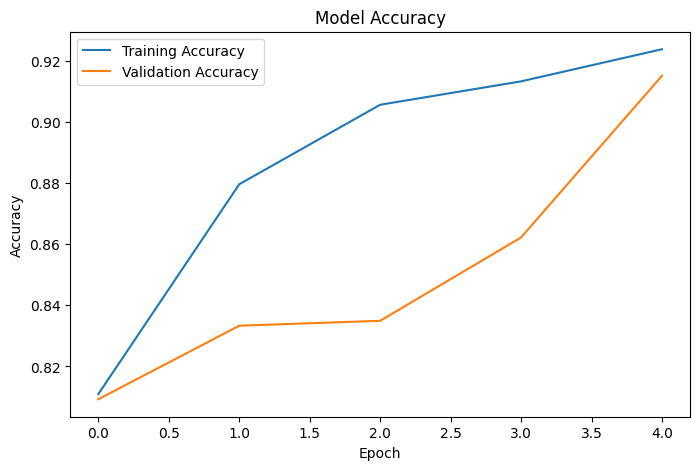

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()

plt.show()

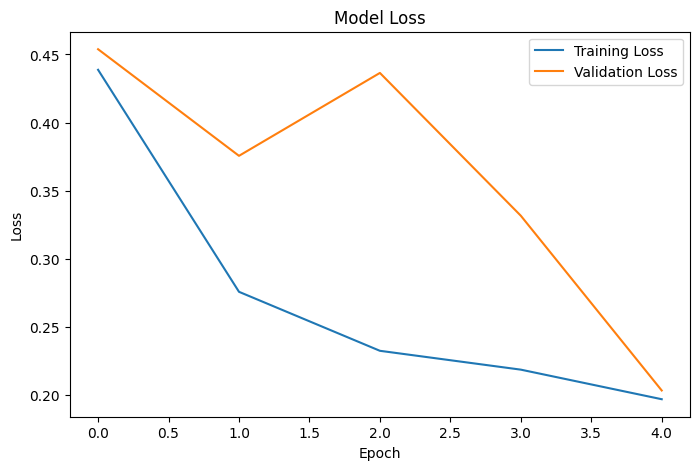

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()

plt.show()

In [11]:
from tensorflow.keras.preprocessing import image

img_path = test_generator.filepaths[0]

img = image.load_img(img_path, target_size=(150,150))
img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Prediction: Pneumonia")
else:
    print("Prediction: Normal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step
Prediction: Normal


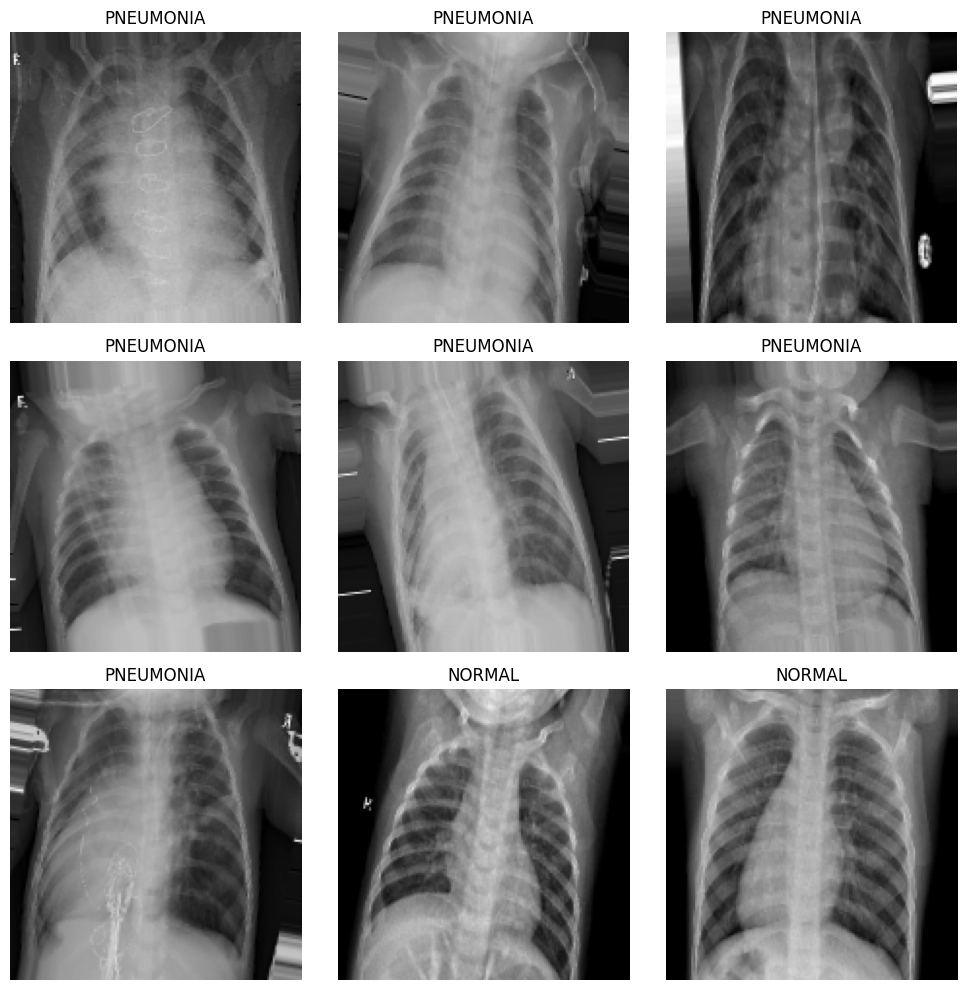

In [12]:
import matplotlib.pyplot as plt

# Get one batch of images and labels
images, labels = next(train_generator)

# Display first 9 images
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])

    if labels[i] == 1:
        plt.title("PNEUMONIA")
    else:
        plt.title("NORMAL")

    plt.axis("off")

plt.tight_layout()
plt.show()

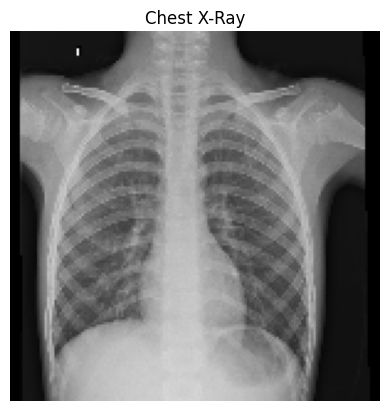

In [13]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# First image in the test dataset
img_path = test_generator.filepaths[0]

img = image.load_img(img_path, target_size=(150,150))

plt.imshow(img)
plt.title("Chest X-Ray")
plt.axis("off")
plt.show()

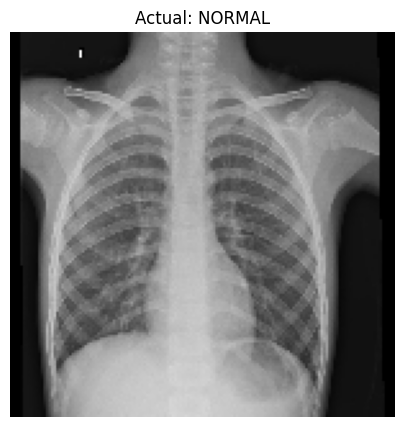

In [15]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = test_generator.filepaths[0]

img = image.load_img(img_path, target_size=(150,150))

plt.figure(figsize=(5,5))
plt.imshow(img)

if test_generator.labels[0] == 1:
    plt.title("Actual: PNEUMONIA")
else:
    plt.title("Actual: NORMAL")

plt.axis("off")
plt.show()